# Introduction
To start my journey into data science, I'll analyse this dataset taken from Kaggle that contains real information about passengers on board of the famous ship Titanic.
The question to answer with this data is whether there is a relation between the features of the passengers and the fact of surviving or not. This will be followed by the application of machine learning to predict, based on the characteristics of a passenger, whether they survived or not.

The project is organised in the following stages:

1. understanding the dataset and checking data quality,
2. cleaning and preparing the data,
3. running plausibility checks,
4. exploratory analysis on focused questions,
5. choosing a machine learning method to predict survival,
6. summarising findings, limitations and next steps.

## 1. Import libraries and load the dataset

I start with the essential libraries only:

- `pandas` for data manipulation,
- `matplotlib.pyplot` for charts,
- `numpy` for some array operations later on.

I also set a clean default chart style so the visual output stays consistent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# load the dataset
t_s = pd.read_csv('datasets/Titanic-Dataset.csv', index_col=0)

# first look at the data
t_s.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Understand the dataset

Before cleaning or plotting anything, I check what the dataset looks like:

- the number of rows and columns,
- the column names,
- the data types,
- basic summary statistics,
- missing values.

This step answers a key question early: **is the dataset ready for analysis, or are there issues that must be fixed first?**

In [3]:
print(f'Number of rows and columns: \n{t_s.shape}')
print('='*40)
print(f'Column names:\n{t_s.columns.to_list()}')
print('='*40)
print(f'Type of columns:\n{t_s.dtypes}')
print('='*40)
print(f'Statistics from the table:\n{t_s.describe()}')
print('='*40)
print(f'Number of empty values per column:\n{t_s.isna().sum()}')

Number of rows and columns: 
(891, 11)
Column names:
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Type of columns:
Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object
Statistics from the table:
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    

### Initial observations

From the first inspection, the dataset already provides useful passenger information: Survived, Pclass, Sex, Fare, Embarked...

This first check also reveals the following:

1. The column Age contains 177 empty values out of 891. We will have to fill those during the next step.
2. The column Cabin has even more empty values, 687 out of 891. It might not make sense to fill it since that data is missing in more than 75% of the rows.
3. From the statistics table we can see that there are no outliers or abnormal values in the numeric columns.
4. Each column has its corresponding type.

# 3. Clean and prepare the data
The purpose of cleaning is not just to make the code run. It is to make the analysis more reliable and the outputs easier to interpret.
Here we perform actions like:
1. Rename unclear columns (for example "SibSp" is replaced by "# siblings and spouses")
2. Choosing how to fill empty values
3. Checking that there are no duplicates (for example the same name twice; here the name is a combination of first name and surname, so there shouldn't be two entries with the same combination)
4. Checking categorical columns like Cabin or Embarked

In [4]:
# we replace the column name "SibSp" by "# siblings and spouses"
t_s = t_s.rename(columns={'SibSp':'# siblings and spouses', 'Parch':'# parents and children'})

In [5]:
# check whether the same person exists twice
duplicate_names = t_s[["Name"]].duplicated()
print(f'Duplicate names: {t_s.loc[duplicate_names, ["Name"]]}')

Duplicate names: Empty DataFrame
Columns: [Name]
Index: []


In [6]:
# check the categories of Pclass, Survived and Embarked, since those look like the categorical columns
cl_categories = ['Pclass', 'Survived', 'Embarked']
for cl in cl_categories:
    print(f'The column {cl} has the following categories: \n{t_s[cl].unique().tolist()}')

The column Pclass has the following categories: 
[3, 1, 2]
The column Survived has the following categories: 
[0, 1]
The column Embarked has the following categories: 
['S', 'C', 'Q', nan]


### Filling in the missing ages

The Age column has about 20% missing values, which is too large a share to just fill in with the overall mean - that would flatten out a lot of the real variation in the data.

My idea is that age and Pclass might be related: older, wealthier passengers were probably more likely to travel in a more comfortable (1st) class. If that holds, filling the missing ages with the median age for the corresponding Pclass should give a better estimate than a single global median.

In [7]:
ratio_missing_age = t_s['Age'].isna().sum() / len(t_s)
print(f'Percentage of missing values in the column Age: {ratio_missing_age*100:.0f}%')

median_by_class = t_s.groupby('Pclass')['Age'].median()
print(median_by_class)

# fill the missing ages with the median age of the corresponding Pclass
t_s['Age'] = t_s['Age'].fillna(t_s['Pclass'].map(median_by_class))
print(f"Number of missing values in column Age: {t_s['Age'].isna().sum()}")

Percentage of missing values in the column Age: 20%
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64
Number of missing values in column Age: 0


As suspected, the median age does decrease as Pclass increases (1st class passengers are older on average than 3rd class ones), so grouping by Pclass before filling makes sense here. After filling, the Age column has no missing values left.

### Dropping the Cabin column

Cabin is missing for 687 out of 891 passengers, i.e. over 75% of the rows. With that much missing data, the column wouldn't be very useful as a feature for modelling later on, so I'll just drop it rather than try to fill or encode it.

In [8]:
t_s = t_s.drop(columns='Cabin')
t_s.head()

,Survived,Pclass,Name,Sex,Age,# siblings and spouses,# parents and children,Ticket,Fare,Embarked
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Dealing with the missing Embarked values

Embarked has only a couple of missing values (less than 1% of the dataset), so instead of trying to fill them in I'll just drop those rows - the impact on the rest of the dataset is negligible.

In [9]:
ratio_null_Embarked = t_s['Embarked'].isna().sum() / len(t_s)
print(f'Percentage of missing values in column Embarked: {ratio_null_Embarked*100:.2f}%')

t_s = t_s.dropna(subset=['Embarked'])

Percentage of missing values in column Embarked: 0.22%


## 4. Plausibility checks

It is also important to check whether the data makes sense after handling missing values and labels.

I will just make sure there aren't any suspicious values. In particular I'll check:
1. Excessively high or negative fares
2. People with an implausibly high (or negative) number of siblings/spouses or parents/children on board
3. People with an implausible age (like > 100 or negative)
4. Underage passengers with 0 parents/children registered on board

To check the first three I'll use the `describe()` method. For the last one I'll filter and count underage passengers with 0 in the "# parents and children" column.

In [10]:
# look for outliers in the numeric columns
print(t_s[['Age', 'Fare', '# siblings and spouses', '# parents and children']].describe())

# median fare by class, to put the max fare value into context (the median is less sensitive to outliers than the mean)
print(t_s.groupby('Pclass')['Fare'].median())

              Age        Fare  # siblings and spouses  # parents and children
count  889.000000  889.000000              889.000000              889.000000
mean    29.019314   32.096681                0.524184                0.382452
std     13.209814   49.697504                1.103705                0.806761
min      0.420000    0.000000                0.000000                0.000000
25%     22.000000    7.895800                0.000000                0.000000
50%     26.000000   14.454200                0.000000                0.000000
75%     36.500000   31.000000                1.000000                0.000000
max     80.000000  512.329200                8.000000                6.000000
Pclass
1    58.6896
2    14.2500
3     8.0500
Name: Fare, dtype: float64


Nothing in the `describe()` output looks like a data-entry error: ages range from a few months old to 80, and the number of siblings/spouses and parents/children on board are all small non-negative integers.

The Fare column is the only one with a value that stands out: the median fare for 1st class is around 60, while the most expensive ticket cost over 500 - roughly 8-9 times the median. I'd consider this plausible rather than an error, since that passenger could simply have paid for one of the most luxurious cabins/suites available.

In [11]:
# underage passengers with 0 registered parents/children on board
underage_no_parents = t_s[(t_s['Age'] < 18) & (t_s['# parents and children'] == 0)]
print(f'Number of underage passengers with 0 registered parents/children on board: {underage_no_parents.shape[0]}')

Number of underage passengers with 0 registered parents/children on board: 32


There are 32 underage passengers with no parents/children on board. This isn't necessarily an error - they could have been travelling with other relatives such as older siblings, grandparents, aunts or uncles, who wouldn't show up in this particular column. I'll leave these rows as they are.

## 5. Exploratory analysis

After the data audit and cleaning, I move on to exploratory data analysis (EDA).

The aim is not to prove causality, but to look for patterns that might be useful for the machine learning step afterwards. I will answer the following questions:

1. What is the overall survival rate?
2. Does the survival rate vary by Pclass? (I could also look at Fare, but since these two columns are related and grouping by Pclass is simpler, I'll use this one.)
3. Does the survival rate vary by gender?
4. Is the survival rate influenced by the number of family members on board?
5. Is the survival rate impacted by age?

This should give an idea of how strong each feature is in relation to survival, before moving on to modelling.

### 5.1 Overall survival rate

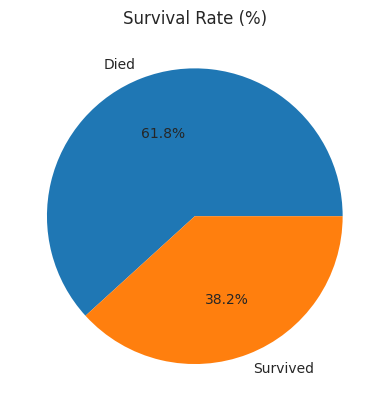

In [12]:
survival_counts = t_s['Survived'].value_counts()
survival_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Died', 'Survived'])
plt.title('Survival Rate (%)')
plt.ylabel('')
plt.show()

More than 60% of the people on board died. This suggests the Titanic may not have had enough lifeboats for everyone, or that the evacuation itself wasn't coordinated effectively enough.

### 5.2 Survival rate by Pclass

Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


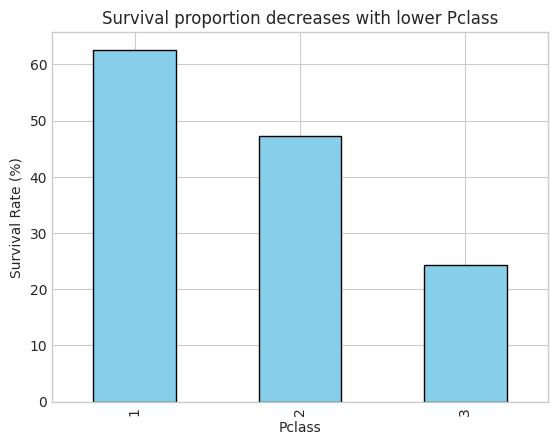

In [13]:
survival_rate_by_Pclass = t_s.groupby('Pclass')['Survived'].mean() * 100
print(survival_rate_by_Pclass)

survival_rate_by_Pclass.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Survival proportion decreases with lower Pclass')
plt.ylabel('Survival Rate (%)')
plt.show()

Survival drops a lot as Pclass goes from 1 to 3 - from about 63% down to roughly 24%. I'd expect Pclass to be one of the stronger predictors once we get to the machine learning step.

### 5.3 Survival rate by gender

Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64


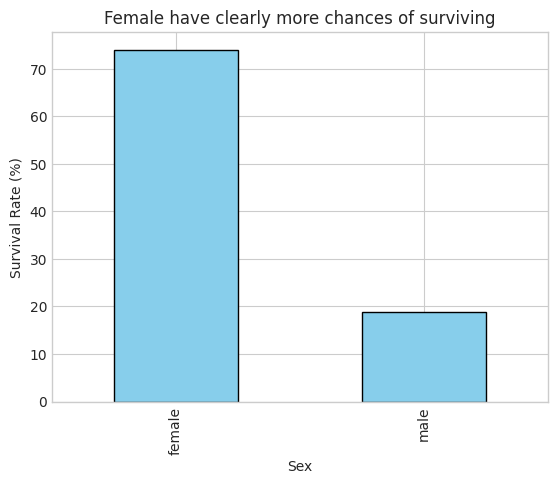

In [14]:
survival_ratio_by_gender = t_s.groupby('Sex')['Survived'].mean() * 100
print(survival_ratio_by_gender)

survival_ratio_by_gender.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Female have clearly more chances of surviving')
plt.ylabel('Survival Rate (%)')
plt.show()

The difference here is huge: around 74% of women survived, versus only about 19% of men. This is by far the clearest pattern so far, and it lines up with the "women and children first" evacuation priority.

### 5.4 Survival rate by number of family members on board

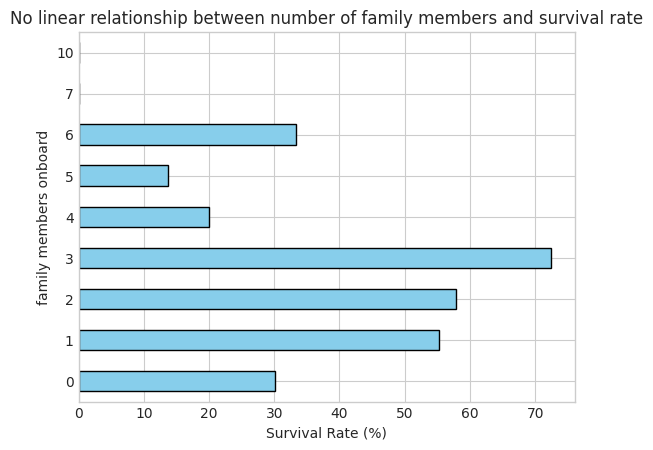

In [15]:
# total number of family members on board = siblings/spouses + parents/children
t_s['family members onboard'] = t_s['# parents and children'] + t_s['# siblings and spouses']

survival_ratio_by_family = t_s.groupby('family members onboard')['Survived'].mean() * 100

# horizontal bars since there are quite a few categories
survival_ratio_by_family.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('No linear relationship between number of family members and survival rate')
plt.xlabel('Survival Rate (%)')
plt.show()

There's no clear linear relationship between the number of family members on board and the survival rate - it goes up and down depending on the group size, with no consistent trend in either direction.

### 5.5 Survival rate by age group

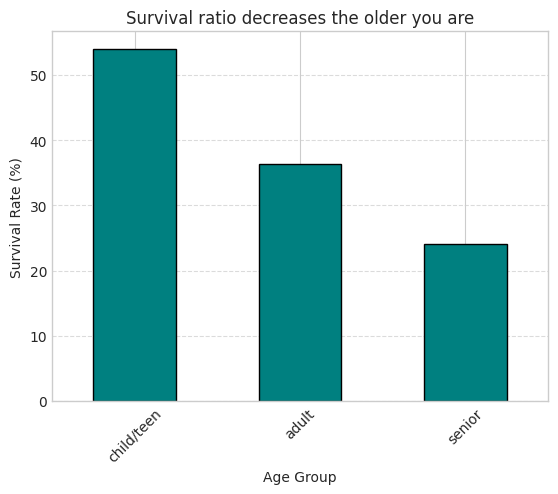

In [16]:
# define age groups: child/teen, adult (up to 60), senior
bins = [0, 18, 60, 100]
labels = ['child/teen', 'adult', 'senior']
t_s['AgeGroup'] = pd.cut(t_s['Age'], bins=bins, labels=labels, right=False)

survival_by_age = t_s.groupby('AgeGroup')['Survived'].mean() * 100

survival_by_age.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Survival ratio decreases the older you are')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Survival rate clearly decreases with age group, going from children/teens down to seniors. This fits the idea that younger passengers were given priority access to the lifeboats.

## 6. Application of machine learning

Now that the data is cleaned and the EDA is done, I have everything I need to apply a machine learning method to predict whether a passenger survived, based on the features in the table.

Based on the EDA above, I expect Pclass, gender and age group to have the biggest impact on the prediction. I'll drop the columns that won't add value or that are redundant with other columns: `Name`, `AgeGroup`, `Ticket` and `family members onboard`.

Before feeding the data to a model, it needs to be transformed depending on which model is used. The target is binary (1 = survived, 0 = died) and the inputs include both numerical and categorical columns. A few model types could work here:

1. **GaussianNB**: categorical columns need to be one-hot encoded, and numerical columns like Age or Fare should be normalised so columns with a larger range don't dominate the others.
2. **Logistic Regression**: same idea as above - categorical columns encoded, numerical columns normalised.
3. **Decision Trees / Random Forest**: these work with both categorical and numerical values, but categorical columns still need to be either one-hot encoded (if there's no inherent order) or ordinal-encoded (if there is, which is the case for Pclass since 1 is a "better" class than 3). Numerical values don't need normalising since tree-based models are scale-invariant.

I'll test all three and pick the one that performs best, comparing their accuracy. To keep things simple, I'll one-hot encode the categorical columns and normalise the numerical ones, so the same preprocessed dataset can be used for all three models.

For splitting the data into training and test sets, a common approach is an 80/20 split. But since that split is random, the test set might happen to over- or under-represent certain types of cases, which can make the evaluation a bit noisy. To avoid that, I'll use 5-fold cross-validation: the data is split into 5 groups, and each model is trained and tested 5 times, each time with a different group held out as the test set. I'll then pick the model that performs best on average across these 5 runs.

In [17]:
from sklearn.model_selection import cross_val_score  # split the data into 5 folds and train/test 5 times with a different test fold each time
from sklearn.compose import ColumnTransformer  # apply StandardScaler and OneHotEncoder in one go, without splitting the table manually
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # normalise numerical columns and encode categorical ones
from sklearn.pipeline import Pipeline  # chain preprocessing and model into a single object

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# build the dataset for machine learning
dataset = t_s.drop(columns=['Name', 'AgeGroup', 'Ticket', 'family members onboard'])
dataset.head()

X = dataset[['Pclass', 'Sex', 'Age', '# siblings and spouses', '# parents and children', 'Fare', 'Embarked']]
y = dataset['Survived']

# preprocessing is shared between all three models
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Age', '# siblings and spouses', '# parents and children', 'Fare']),
    ('cat', OneHotEncoder(drop='first'), ['Pclass', 'Sex', 'Embarked'])
])

# one pipeline per model, stored in a dict so it's easy to loop over
pipelines = {
    'RF': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))]),
    'GNB': Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'LR': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(random_state=42))])
}

# 5-fold cross-validation for each model
scores_dict = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    scores_dict[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

RF: 0.8099 ± 0.0365
GNB: 0.7739 ± 0.0375
LR: 0.7987 ± 0.0252


Random Forest gives the best average accuracy, closely followed by Logistic Regression (about 1 percentage point behind). Logistic Regression also has a noticeably lower standard deviation across folds (around 0.025 vs 0.037 for Random Forest), meaning its performance is more stable from fold to fold.

So there's a trade-off here: Random Forest for raw accuracy, or Logistic Regression for simplicity and stability. I'll go with **Logistic Regression** - the accuracy difference is small, and it has the added benefit of giving interpretable coefficients, which lets me check whether the most important features match my expectations from the EDA. `cross_val_score` doesn't give access to the fitted models though, so I'll use `cross_validate` instead to also get the coefficients.

In [18]:
from sklearn.model_selection import cross_validate

# return_estimator=True gives access to the 5 fitted pipelines
cv_results_LR = cross_validate(pipelines['LR'], X, y, cv=5, return_estimator=True)
fitted_pipeline_LR = cv_results_LR['estimator']

print("Coefficients for each fold:")
for i, pipeline in enumerate(fitted_pipeline_LR):
    print(f"Fold {i+1} coefficients: {pipeline.named_steps['clf'].coef_}")

Coefficients for each fold:
Fold 1 coefficients: [[-0.47469071 -0.25384377 -0.11948144  0.26537829 -0.81174657 -2.01443901
  -2.45715746 -0.37298251 -0.51064985]]
Fold 2 coefficients: [[-0.5036278  -0.43538026 -0.07504023  0.08944533 -0.78781757 -2.24771216
  -2.67062765 -0.31664935 -0.47495559]]
Fold 3 coefficients: [[-0.56101828 -0.3941048  -0.08755621  0.29710135 -0.74472316 -1.84125292
  -2.54116594 -0.08535164 -0.4110642 ]]
Fold 4 coefficients: [[-0.53695207 -0.44277553  0.07662929  0.11411974 -0.76624487 -1.86295696
  -2.5959303   0.17991567 -0.30581358]]
Fold 5 coefficients: [[-0.43597161 -0.28021406 -0.12362992  0.10775706 -0.65801057 -1.93698368
  -2.55044446  0.01960121 -0.34637494]]


In [19]:
# average the coefficients across the 5 folds
coef_list = [pipe.named_steps['clf'].coef_ for pipe in fitted_pipeline_LR]
avg_coefs = np.mean(coef_list, axis=0)

# feature names after one-hot encoding (more columns than in the original dataset)
feature_names = fitted_pipeline_LR[0].named_steps['prep'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': avg_coefs[0],
    'abs_coefficient': np.abs(avg_coefs[0])
})
coef_df_sorted = coef_df.sort_values('abs_coefficient', ascending=False)
print(coef_df_sorted)

                       feature  coefficient  abs_coefficient
6                cat__Sex_male    -2.563065         2.563065
5                cat__Pclass_3    -1.980669         1.980669
4                cat__Pclass_2    -0.753709         0.753709
0                     num__Age    -0.502452         0.502452
8              cat__Embarked_S    -0.409772         0.409772
1  num__# siblings and spouses    -0.361264         0.361264
3                    num__Fare     0.174760         0.174760
7              cat__Embarked_Q    -0.115093         0.115093
2  num__# parents and children    -0.065816         0.065816


The three most important features for predicting survival are gender, Pclass and age, which matches what I expected from the EDA. The advantage of Logistic Regression is that it also tells us *how* each feature affects the outcome and in which direction.

Being male has a strongly negative coefficient, and so does being in 3rd class - both heavily reduce the chance of survival. 2nd class has a smaller negative effect, which suggests 1st class would have a positive effect by comparison.

Note that "Pclass_1" and "Sex_female" don't appear in the table - that's because `OneHotEncoder(drop='first')` drops one category per column as a reference. So a row where `cat__Sex_male = 0` represents a female passenger, and a row where both `cat__Pclass_2` and `cat__Pclass_3` are 0 represents a 1st class passenger.

## 7. Summary, limitations and next steps

**Findings**: gender, Pclass and age turned out to be the strongest predictors of survival, which lines up with both the EDA and the historical "women and children first" evacuation policy. Logistic Regression and Random Forest both reach around 80% accuracy on this dataset, with Logistic Regression being the more stable of the two across folds.

**Limitations**:
- The missing ages were filled with the median age per Pclass, which is a reasonable approximation but still an assumption - it could be smoothing out real differences within each class.
- The Cabin column was dropped entirely due to the high proportion of missing values, even though the cabin's location on the ship could plausibly be related to survival.
- The "family members onboard" feature didn't show a clear linear pattern with survival rate, which suggests it might need a different treatment (e.g. binning into "alone" vs "with family") rather than just being dropped.

**Next steps**:
- Try a few more model types (for example SVM) and compare them against this baseline.
- Engineer additional features, such as the title extracted from the Name column (Mr, Mrs, Miss, Master, etc.), which is a well-known useful feature for this dataset.
- Tune the hyperparameters of the Random Forest (for example max_depth, n_estimators, max_features...  ), since its higher standard deviation across folds suggests there might be some overfitting that regularisation could help with.